In [106]:

import pandas as pd
import numpy as np

# Conectando ao Google Drive (SE NECESSÁRIO)
from google.colab import drive
drive.mount("/content/drive")

# Alterando a pasta de trabalho (SE NECESSÁRIO)
%cd /content/drive/MyDrive/Mate_homework

sales_data = pd.read_csv("sales_data.csv", nrows=100)
sales_data.head()



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Mate_homework


,Order_Date,Time,Aging,Customer_Id,Gender,Device_Type,Customer_Login_type,Product_Category,Product,Sales,Quantity,Discount,Profit,Shipping_Cost,Order_Priority,Payment_method
0,2018-01-01,10:11:40,5,29317,Male,Web,Member,Auto & Accessories,Car Media Players,140,4,0.3,43.2,4.3,Medium,e_wallet
1,2018-01-01,22:30:44,7,42270,Male,Web,Member,Auto & Accessories,Car Pillow & Neck Rest,231,5,0.1,139.5,13.9,High,money_order
2,2018-01-01,21:55:31,10,14563,Male,Web,Member,Auto & Accessories,Car Speakers,211,5,0.1,120.5,12.0,High,credit_card
3,2018-01-01,13:57:15,9,58601,Male,Web,Member,Auto & Accessories,Tyre,250,4,0.2,150.0,15.0,Critical,credit_card
4,2018-01-01,15:17:41,2,48342,Male,Web,Member,Auto & Accessories,Tyre,250,1,0.1,165.0,16.5,High,credit_card


**Data Transformation**

In [107]:
#Data Transformation

sales_data["Order_Date"] = pd.to_datetime(
    sales_data["Order_Date"].astype(str) + " " + sales_data["Time"],
    format="%Y-%m-%d %H:%M:%S"
)

sales_data = sales_data.drop("Time", axis=1)

sales_data["sales_amount"] = sales_data["Sales"] * sales_data["Quantity"]


sales_data["Gender"] = sales_data["Gender"].replace({
    "Male": "M",
    "Female": "F"
})

sales_data.columns = sales_data.columns.str.lower()


sales_data.head()
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   order_date           100 non-null    datetime64[ns]
 1   aging                100 non-null    int64         
 2   customer_id          100 non-null    int64         
 3   gender               100 non-null    object        
 4   device_type          100 non-null    object        
 5   customer_login_type  100 non-null    object        
 6   product_category     100 non-null    object        
 7   product              100 non-null    object        
 8   sales                100 non-null    int64         
 9   quantity             100 non-null    int64         
 10  discount             100 non-null    float64       
 11  profit               100 non-null    float64       
 12  shipping_cost        100 non-null    float64       
 13  order_priority       100 non-null   

A análise da métrica de faturamento (sales_amount) revela que o valor máximo observado foi 1155.0, enquanto o valor mínimo foi 54.0. O faturamento total atingiu 37433.0, com uma média de 374.33 por transação e mediana de 248.00. Esses indicadores fornecem uma visão geral da distribuição das vendas, permitindo identificar padrões e possíveis outliers.
A empresa comercializa produtos em 4 categorias distintas. Em termos de popularidade, as categorias mais frequentes são: Fashion, Home & Furniture, Auto & Accessories, com destaque para Fashion como a mais recorrente. Isso indica uma maior demanda concentrada nessas categorias.
Os cinco produtos mais populares são Running Shoes, Sneakers, Towels, Shirts, Titak watch. O produto mais vendido é Running Shoes, indicando forte preferência dos clientes. Esses produtos representam uma parcela significativa das vendas e podem ser considerados estratégicos para o negócio.
A análise do comportamento de compra por gênero indica que os homens compram 

<Axes: xlabel='product_category'>

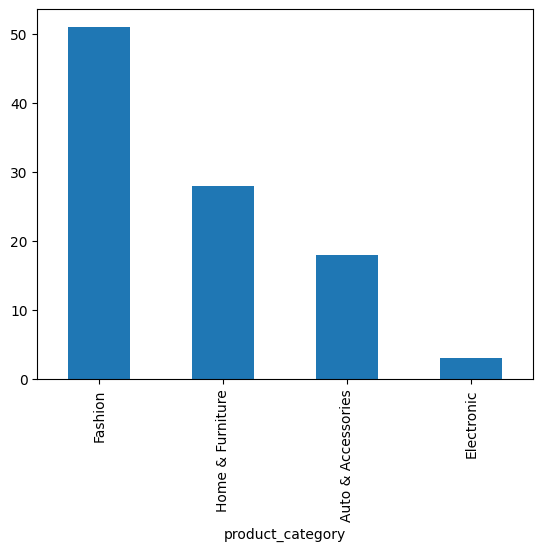

In [117]:
#Descriptive Analytics

#Qual é o valor máximo e mínimo de vendas (sales_amount)?
#Qual é o total, a média e a mediana dessa métrica?


metricas = sales_data["sales_amount"].agg(
    maximo="max",
    minimo="min",
    total="sum",
    media="mean",
    mediana="median"
)

print(
    f"A análise da métrica de faturamento (sales_amount) revela que o valor máximo observado foi {metricas['maximo']}, "
    f"enquanto o valor mínimo foi {metricas['minimo']}. O faturamento total atingiu {metricas['total']}, "
    f"com uma média de {metricas['media']:.2f} por transação e mediana de {metricas['mediana']:.2f}. "
    f"Esses indicadores fornecem uma visão geral da distribuição das vendas, permitindo identificar padrões e possíveis outliers."
)


#Quantas categorias de produtos a empresa vende?
#Qual é a popularidade de cada categoria?

num_categorias = sales_data["product_category"].nunique()
popularidade = sales_data["product_category"].value_counts()

print(
    f"A empresa comercializa produtos em {num_categorias} categorias distintas. "
    f"Em termos de popularidade, as categorias mais frequentes são: "
    f"{', '.join(popularidade.index[:3])}, com destaque para {popularidade.index[0]} como a mais recorrente. "
    f"Isso indica uma maior demanda concentrada nessas categorias."
)


#Nomeie os 5 produtos mais populares

top_5 = sales_data["product"].value_counts().head(5)

print(
    f"Os cinco produtos mais populares são {', '.join(top_5.index)}. "
    f"O produto mais vendido é {top_5.index[0]}, indicando forte preferência dos clientes. "
    f"Esses produtos representam uma parcela significativa das vendas e podem ser considerados estratégicos para o negócio."
)

#Quem compra com mais frequência, mulheres ou homens?

freq_genero = sales_data["gender"].value_counts()

print(
    f"A análise do comportamento de compra por gênero indica que "
    f"{'os homens' if freq_genero.index[0] == 'M' else 'as mulheres'} compram com mais frequência. "
    f"Foram registrados {freq_genero.iloc[0]} pedidos para o grupo mais ativo, "
    f"contra {freq_genero.iloc[1]} para o outro grupo. "
    f"Esse resultado evidencia uma diferença no engajamento entre os públicos."
)

pagamento = sales_data["payment_method"].value_counts()
top_pagamento = pagamento.idxmax()

print(
    f"O método de pagamento mais utilizado pelos clientes é {top_pagamento}. "
    f"Esse método se destaca como a principal escolha nas transações realizadas, "
    f"indicando uma preferência clara que pode orientar estratégias de pagamento e parcerias comerciais."
)

sales_data["product_category"].value_counts().plot(kind="bar")